# 🎵 Vocal → MIDI → Sheet (with Smart Harmony) — Complete Pipeline

This notebook demonstrates an end‑to‑end pipeline:

1. **Converting Vocal to MIDI** (librosa + **PYIN** pitch detection)  
2. **Pitch Detection & Note Segmentation** (frame → discrete notes)  
3. **MIDI to Sheet** (render a score with **music21**)  
4. **Intelligent Harmony Generation** (melody-aware chord selection with **music21**)
5. **Melody Prediction** (Markov chain model for generating melodic variations)

> **Inputs:** A vocal recording (e.g., `vocals.wav` or `song.mp3`)  
> **Outputs:** 
> - `melody.mid` / `melody.musicxml` - Detected vocal melody
> - `score.mid` / `score.musicxml` - Melody + smart harmony
> - `predicted_melody.mid` / `predicted_melody.musicxml` - ML-generated melody
> - `melody_comparison.png` - Visual comparison
> - `evaluation_report.json` - Quality metrics

**Tip:** Run cells top‑to‑bottom. Replace `AUDIO_FILE` with your file path.

In [ ]:

# --- Setup (uncomment if running in a fresh environment) ---
# %pip install librosa==0.10.1 music21==9.1.0 matplotlib==3.9.0 soundfile==0.12.1 pretty_midi
# If you have an MP3 file, install ffmpeg in your environment so librosa can load it.
# On Colab: !apt-get -y install ffmpeg


  DEPRECATION: Building 'pretty_midi' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pretty_midi'. Discussion can be found at https://github.com/pypa/pip/issues/6334



     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ---------------------------------------  5.5/5.6 MB 27.9 MB/s eta 0:00:01
     ---------------------------------------- 5.6/5.6 MB 20.1 MB/s  0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595992 sha256=c8570df9a80bd6af535f50985af07ae1ebc9af0e85b60b69fe42600f31f1eb06
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\1c\34\7f\bfb7839bb83bde9760012a22955bada5fcd50c67ff426ccf40
Successfully built pretty_midi

   ---------------------------------------- 0/3 [mido]
   ---------------------------------------- 0/3 [mido]
   ---------------------------------------- 0/3 [mido]
   ---------------------------------------- 0/3 [mido]
   ---------------------------------------- 0/3 [mido]
   ---------------------------------------- 0/3 [mido]
   ---------------

In [1]:

from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from music21 import stream, note, chord, tempo, meter, key as m21key, midi as m21midi, metadata, analysis

# ---- Config ----
AUDIO_FILE = "Input/test_melody.mp3"  # <-- change this to your file path (e.g., "your_song.mp3")
OUTPUT_DIR = Path("outputs_week8")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Pitch detection configuration
FMIN = librosa.note_to_hz('C2')
FMAX = librosa.note_to_hz('C7')
FRAME_HOP = 256  # hop_length
SR_TARGET = 22050


c:\Users\user\anaconda3\envs\lora\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


C:\Users\user\AppData\Local\Temp\ipykernel_18848\1230218905.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(AUDIO_FILE, sr=SR_TARGET, mono=True)
c:\Users\user\anaconda3\envs\lora\lib\site-packages\librosa\core\audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded Input/test_melody.mp3 | sr=22050 | duration=6.40s


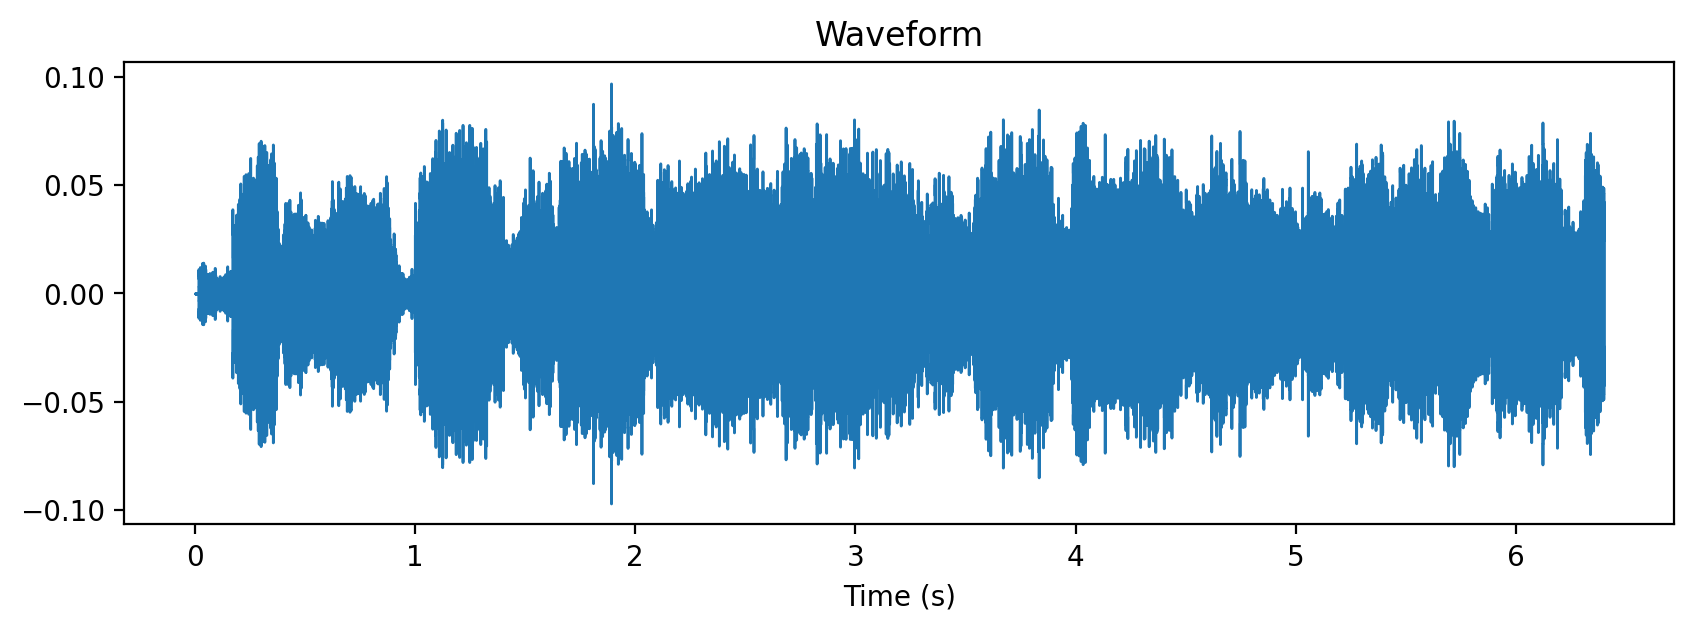

In [2]:
# ---- Load audio ----
y, sr = librosa.load(AUDIO_FILE, sr=SR_TARGET, mono=True)
duration_sec = len(y) / sr
print(f"Loaded {AUDIO_FILE} | sr={sr} | duration={duration_sec:.2f}s")

# ---- Visualize waveform (optional) ----
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr, color='C0')  # <-- add color
plt.title("Waveform"); plt.xlabel("Time (s)")
plt.show()


PYIN: frames=552 | voiced=234


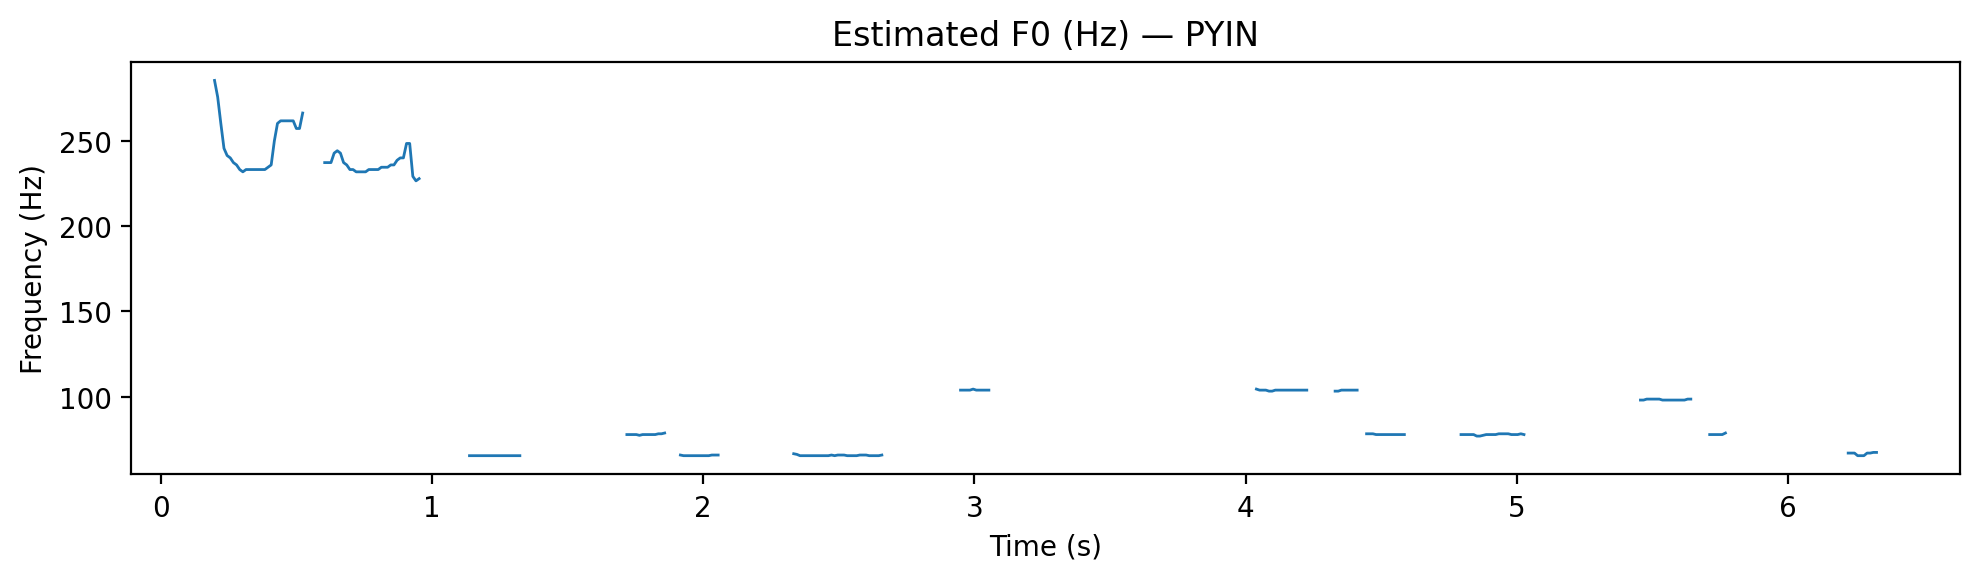

In [3]:

# ---- Pitch detection with PYIN ----
f0, voiced_flag, voiced_probs = librosa.pyin(
    y, fmin=FMIN, fmax=FMAX, sr=sr, hop_length=FRAME_HOP
)
times = librosa.times_like(f0, sr=sr, hop_length=FRAME_HOP)

print("PYIN:", f"frames={len(f0)} | voiced={(voiced_flag==True).sum()}")

# Plot F0 track
plt.figure(figsize=(10, 3))
plt.plot(times, f0, linewidth=1)
plt.title("Estimated F0 (Hz) — PYIN")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


In [5]:

def hz_to_midi_pitch(freq_hz: float):
    """Return a music21 Note from frequency in Hz."""
    n = note.Note()
    n.pitch.frequency = float(freq_hz)
    return n

def segment_notes(times, f0, min_note_len=0.12, pitch_tolerance_semitones=0.5):
    """
    Convert framewise pitch into segmented notes.
    - min_note_len: minimum duration (s) to keep a note
    - pitch_tolerance_semitones: merge frames if pitch change < tolerance
    """
    import numpy as np
    segments = []
    current = {"start": None, "fvals": []}

    def flush(end_time):
        if current["start"] is None or len(current["fvals"]) == 0:
            return
        start_t = current["start"]
        dur = end_time - start_t
        if dur >= min_note_len:
            freq = float(np.median(current["fvals"]))
            segments.append((start_t, end_time, freq))
        current["start"], current["fvals"] = None, []

    last_freq = None
    for t, f in zip(times, f0):
        if f is None or np.isnan(f):
            # end of a voiced region
            flush(t)
            last_freq = None
            continue
        if current["start"] is None:
            # start new segment
            current["start"] = float(t)
            current["fvals"] = [float(f)]
            last_freq = float(f)
        else:
            # continue or split if pitch jump > tolerance
            semitone_diff = 0.0 if (last_freq is None) else 12*np.log2(float(f)/last_freq)
            if abs(semitone_diff) > pitch_tolerance_semitones:
                flush(t)
                current["start"] = float(t)
                current["fvals"] = [float(f)]
            else:
                current["fvals"].append(float(f))
            last_freq = float(f)

    # flush tail
    flush(times[-1] if len(times) else 0.0)
    return segments

segments = segment_notes(times, f0)
print(f"Segmented notes: {len(segments)}")
segments[:5]


Segmented notes: 10


[(0.23219954648526078, np.float64(0.4179591836734694), 233.08188075904494),
 (0.603718820861678, np.float64(0.905578231292517), 235.1111360581255),
 (1.1377777777777778, np.float64(1.3351473922902495), 65.40639132514966),
 (1.7182766439909296, np.float64(1.8692063492063493), 77.78174593052022),
 (1.9156462585034013, np.float64(2.066575963718821), 65.40639132514966)]

In [6]:

# ---- Build melody part ----
melody = stream.Part()
melody.id = "Melody"

# Basic time signature & tempo (can be estimated/edited)
melody.append(meter.TimeSignature('4/4'))
melody.append(tempo.MetronomeMark(number=90))

for (t0, t1, freq) in segments:
    dur = max(0.25, t1 - t0)  # clamp minimum dur
    n = hz_to_midi_pitch(freq)
    # Quantize duration crudely to nearest 0.25 quarterLength
    ql = max(0.25, round(dur / 0.25) * 0.25)
    n.quarterLength = ql
    melody.append(n)

# Save melody as MIDI & MusicXML
melody_midi_fp = OUTPUT_DIR / "melody.mid"
melody_xml_fp  = OUTPUT_DIR / "melody.musicxml"
melody.write('midi', fp=str(melody_midi_fp))
melody.write('musicxml', fp=str(melody_xml_fp))
print("Saved:", melody_midi_fp, "and", melody_xml_fp)


Saved: outputs_week8\melody.mid and outputs_week8\melody.musicxml


In [ ]:
# ---- Intelligent Harmony Generation ----
from pathlib import Path
import numpy as np
from music21 import stream, meter, chord, roman, key as m21key, analysis, metadata, note

# Analyze key on the melody
melody_score = stream.Score()
melody_score.insert(0, melody)
analyzer = analysis.discrete.KrumhanslSchmuckler()
est_key = analyzer.getSolution(melody_score)
print("Estimated Key:", est_key)

# Fallback if analysis returns None / odd type
if not isinstance(est_key, m21key.Key):
    est_key = m21key.Key('C')

# Define diatonic chords available in the key (I, ii, iii, IV, V, vi, vii°)
# Using major key as reference (adjust for minor if needed)
if est_key.mode == 'minor':
    diatonic_rn = ["i", "iio", "III", "iv", "v", "VI", "VII"]  # Natural minor
else:
    diatonic_rn = ["I", "ii", "iii", "IV", "V", "vi", "viio"]  # Major

def get_melody_notes_at_measure(melody_part, measure_num):
    """Extract pitch classes of notes in a specific measure."""
    notes_in_measure = []
    measure_start = (measure_num - 1) * 4.0  # 4/4 time
    measure_end = measure_start + 4.0
    
    for n in melody_part.flatten().notes:
        if hasattr(n, 'pitch'):
            note_offset = float(n.offset)
            if measure_start <= note_offset < measure_end:
                notes_in_measure.append(n.pitch.pitchClass)
    
    return set(notes_in_measure)

def score_chord_fit(chord_rn, melody_pcs, key_obj):
    """
    Score how well a chord fits the melody notes.
    Higher score = better fit.
    """
    try:
        rn = roman.RomanNumeral(chord_rn, key_obj)
        chord_pcs = {p.pitchClass for p in rn.pitches}
    except:
        return -100  # Invalid chord
    
    if not melody_pcs:
        return 0  # No melody notes, neutral
    
    score = 0
    
    # Priority 1: Melody notes should be IN the chord (highest weight)
    notes_in_chord = len(melody_pcs & chord_pcs)
    score += notes_in_chord * 10
    
    # Priority 2: Penalize if melody has notes NOT in chord
    notes_not_in_chord = len(melody_pcs - chord_pcs)
    score -= notes_not_in_chord * 5
    
    # Priority 3: Prefer stable chords (I, IV, V) slightly
    if chord_rn in ["I", "i"]:
        score += 2
    elif chord_rn in ["IV", "iv", "V", "v"]:
        score += 1
    
    return score

def choose_best_chord(melody_pcs, key_obj, available_chords, prev_chord=None):
    """
    Choose the best chord for given melody notes.
    Also considers smooth voice leading from previous chord.
    """
    best_chord = available_chords[0]
    best_score = -1000
    
    for chord_rn in available_chords:
        score = score_chord_fit(chord_rn, melody_pcs, key_obj)
        
        # Bonus: prefer smooth voice leading (stay on same chord or move by fifth/fourth)
        if prev_chord:
            if chord_rn == prev_chord:
                score += 3  # Staying on same chord is smooth
            # Check if it's a fifth/fourth relationship (strong progression)
            try:
                prev_rn = roman.RomanNumeral(prev_chord, key_obj)
                curr_rn = roman.RomanNumeral(chord_rn, key_obj)
                interval_dist = abs(prev_rn.scaleDegree - curr_rn.scaleDegree)
                if interval_dist in [4, 5, 3]:  # Fourth, fifth, or third
                    score += 2
            except:
                pass
        
        if score > best_score:
            best_score = score
            best_chord = chord_rn
    
    return best_chord

# Build intelligent harmony
harmony_part = stream.Part(id="Harmony")
harmony_part.append(meter.TimeSignature('4/4'))

# Estimate number of measures
q_len = getattr(melody.duration, 'quarterLength', None) or melody.duration.quarterLength
num_measures = int(np.ceil(q_len / 4.0))

print(f"\nGenerating harmony for {num_measures} measures...")

prev_chord_rn = None
for measure_num in range(1, num_measures + 1):
    # Get melody notes in this measure
    melody_pcs = get_melody_notes_at_measure(melody, measure_num)
    
    # Choose best chord
    best_chord_rn = choose_best_chord(melody_pcs, est_key, diatonic_rn, prev_chord_rn)
    
    # Create chord
    try:
        rn = roman.RomanNumeral(best_chord_rn, est_key)
        ch = chord.Chord(rn.pitches)
        ch.quarterLength = 4.0  # Whole measure
        harmony_part.append(ch)
        prev_chord_rn = best_chord_rn
        
        print(f"  Measure {measure_num}: {best_chord_rn} (melody notes: {sorted(melody_pcs) if melody_pcs else 'none'})")
    except Exception as e:
        print(f"  Measure {measure_num}: Error creating chord - {e}")
        # Fallback to I chord
        rn = roman.RomanNumeral("I" if est_key.mode != 'minor' else "i", est_key)
        ch = chord.Chord(rn.pitches)
        ch.quarterLength = 4.0
        harmony_part.append(ch)

# Combine parts into a score
score = stream.Score()
score.insert(0, metadata.Metadata())
score.metadata.title = "Harmonized Vocal Transcription (Smart Harmony)"
score.append(melody)
score.append(harmony_part)

# Ensure output dir exists
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_xml_fp = OUTPUT_DIR / "score.musicxml"
score_midi_fp = OUTPUT_DIR / "score.mid"
score.write('musicxml', fp=str(score_xml_fp))
score.write('midi', fp=str(score_midi_fp))
print("\nSaved:", score_xml_fp, "and", score_midi_fp)


Estimated Key: c minor
Saved: outputs_week8\score.musicxml and outputs_week8\score.mid


In [ ]:
# Evaluate melody (audio <-> generated-sheet playback) and harmony metrics (based on provided tables)
import warnings
from pathlib import Path
import numpy as np
import librosa
import json
import pretty_midi
import subprocess
import shutil
import math
from music21 import converter, chord as m21chord, key as m21key

OUTPUT_DIR = Path("outputs_week8")
orig_audio_fp = Path("Input/test_melody.mp3")   # original audio used in pipeline
score_midi_fp = OUTPUT_DIR / "score.mid"        # generated MIDI (harmonized score)
score_xml_fp  = OUTPUT_DIR / "score.musicxml"
render_wav = OUTPUT_DIR / "score_render.wav"
sr = 22050
pyin_hop = 256
FMIN = librosa.note_to_hz('C2')
FMAX = librosa.note_to_hz('C7')

# If MuseScore CLI is available, set it here (full path). Otherwise set to None and optionally provide a SoundFont.
musescore_path = r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe"  # update if different, or set to None
soundfont_path = None  # e.g., r"C:\path\to\GeneralUser.sf2"  (used by pretty_midi.fluidsynth fallback)

# --- Helpers ---
def render_midi_to_wav(midi_fp: Path, out_wav: Path):
    # Try MuseScore CLI first
    if musescore_path:
        exe = Path(musescore_path)
        if exe.exists():
            cmd = [str(exe), "-o", str(out_wav), str(midi_fp)]
            try:
                subprocess.run(cmd, check=True, capture_output=True, text=True)
                return True
            except Exception as e:
                warnings.warn(f"MuseScore render failed: {e}")

    warnings.warn("MuseScore not found. Install MuseScore and set musescore_path correctly.")
    return False

def run_pyin_on_file(audio_fp, sr=22050, hop_length=256, fmin=FMIN, fmax=FMAX):
    y, _sr = librosa.load(str(audio_fp), sr=sr, mono=True)
    f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=fmin, fmax=fmax, sr=sr, hop_length=hop_length)
    times = librosa.times_like(f0, sr=sr, hop_length=hop_length)
    return f0, np.array(voiced_flag, dtype=bool), times, y, sr

def hz_to_midi(freq_hz):
    return 69.0 + 12.0 * np.log2(freq_hz / 440.0)

def cents_error(ref_hz, est_hz):
    return 1200.0 * np.log2(est_hz / ref_hz)

def compute_frame_metrics(y_true_voiced, y_pred_voiced, y_true_freq, y_pred_freq, tolerance_cents=50.0):
    y_true_voiced = np.asarray(y_true_voiced).astype(bool)
    y_pred_voiced = np.asarray(y_pred_voiced).astype(bool)
    y_true_freq = np.asarray(y_true_freq, dtype=float)
    y_pred_freq = np.asarray(y_pred_freq, dtype=float)
    n = y_true_voiced.size

    TP = int(np.sum(y_true_voiced & y_pred_voiced))
    FP = int(np.sum(~y_true_voiced & y_pred_voiced))
    FN = int(np.sum(y_true_voiced & ~y_pred_voiced))
    TN = int(np.sum(~y_true_voiced & ~y_pred_voiced))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    voicing_recall = recall
    voicing_false_alarm = FP / (FP + TN) if (FP + TN) > 0 else 0.0

    voiced_idx = np.where(y_true_voiced)[0]
    raw_pitch_correct = 0
    raw_chroma_correct = 0
    cents_list = []
    ref_list = []
    est_list = []
    for i in voiced_idx:
        if not y_pred_voiced[i]:
            continue
        if y_true_freq[i] <= 0 or y_pred_freq[i] <= 0 or np.isnan(y_true_freq[i]) or np.isnan(y_pred_freq[i]):
            continue
        c_err = cents_error(y_true_freq[i], y_pred_freq[i])
        cents_list.append(c_err)
        ref_list.append(y_true_freq[i])
        est_list.append(y_pred_freq[i])
        if abs(c_err) <= tolerance_cents:
            raw_pitch_correct += 1
        m_true = hz_to_midi(y_true_freq[i])
        m_pred = hz_to_midi(y_pred_freq[i])
        pc_true = int(round(m_true)) % 12
        pc_pred = int(round(m_pred)) % 12
        if pc_true == pc_pred:
            raw_chroma_correct += 1

    n_true_voiced = len(voiced_idx)
    raw_pitch_accuracy = (raw_pitch_correct / n_true_voiced) if n_true_voiced > 0 else np.nan
    raw_chroma_accuracy = (raw_chroma_correct / n_true_voiced) if n_true_voiced > 0 else np.nan

    correct_frames = 0
    for i in range(n):
        if not y_true_voiced[i] and not y_pred_voiced[i]:
            correct_frames += 1
            continue
        if y_true_voiced[i] and y_pred_voiced[i] and y_true_freq[i] > 0 and y_pred_freq[i] > 0:
            c_err = cents_error(y_true_freq[i], y_pred_freq[i])
            if abs(c_err) <= tolerance_cents:
                correct_frames += 1
    overall_accuracy = correct_frames / n if n > 0 else np.nan

    mae_cents = float(np.mean(np.abs(cents_list))) if len(cents_list) > 0 else np.nan
    corr = np.corrcoef(ref_list, est_list)[0,1] if len(ref_list) > 1 else np.nan

    return {
        "F-measure": f1,
        "Precision": precision,
        "Recall": recall,
        "Voicing Recall": voicing_recall,
        "Voicing False Alarm": voicing_false_alarm,
        "Raw Pitch Accuracy": raw_pitch_accuracy,
        "Raw Chroma Accuracy": raw_chroma_accuracy,
        "Overall Accuracy": overall_accuracy,
        "MAE_cents": mae_cents,
        "Correlation": corr,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "n_true_voiced": n_true_voiced, "total_frames": n,
    }

# --- Render generated MIDI to WAV ---
if not score_midi_fp.exists():
    raise FileNotFoundError(f"Generated MIDI not found: {score_midi_fp}")
ok = render_midi_to_wav(score_midi_fp, render_wav)
if not ok:
    raise RuntimeError("Failed to render generated MIDI to WAV. Install MuseScore or set soundfont_path and pretty_midi.")

# --- run PYIN on both original and rendered audio ---
f0_ref, voiced_ref, times_ref, y_ref, sr_ref = run_pyin_on_file(orig_audio_fp, sr=sr, hop_length=pyin_hop)
f0_hat, voiced_hat, times_hat, y_hat, sr_hat = run_pyin_on_file(render_wav, sr=sr, hop_length=pyin_hop)

# align frames by time grid: map hat -> ref by nearest index (simple)
def map_to_ref(times_src, values_src, times_ref):
    idx = np.searchsorted(times_src, times_ref)
    idx = np.clip(idx, 0, len(times_src)-1)
    return values_src[idx]

y_pred_freq_aligned = map_to_ref(times_hat, np.array([np.nan if (f is None or np.isnan(f)) else float(f) for f in f0_hat]), times_ref)
y_pred_voiced_aligned = map_to_ref(times_hat, voiced_hat, times_ref)
y_true_freq = np.array([np.nan if (f is None or np.isnan(f)) else float(f) for f in f0_ref])
y_true_voiced = voiced_ref

# compute melody/frame metrics
melody_metrics = compute_frame_metrics(y_true_voiced, y_pred_voiced_aligned, y_true_freq, y_pred_freq_aligned, tolerance_cents=50.0)
print("=== Melody / Playback vs Original (frame-level) ===")
for k,v in melody_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# --- Harmony metrics ---
# 1) Chord vocabulary & chord list from generated score
if not score_xml_fp.exists():
    raise FileNotFoundError(f"Generated MusicXML not found: {score_xml_fp}")
score_ref = converter.parse(str(score_xml_fp))
if not hasattr(score_ref, "recurse"):
    raise RuntimeError(f"Parsed score is not a music21 stream (type={type(score_ref)}). Check {score_xml_fp}")

generated_chords = []
for el in score_ref.recurse().getElementsByClass(m21chord.Chord):
    onset = float(el.offset)
    dur = float(el.quarterLength)
    pcs = tuple(sorted({p.pitchClass for p in el.pitches}))
    generated_chords.append((onset, onset+dur, pcs, el.pitches))

# chord vocabulary size
vocab = {tuple(pcs) for (_,_,pcs,_) in generated_chords}
chord_vocab_size = len(vocab)

# 2) Simple chord estimation from original audio: chroma + triad templates
y_ref_audio, _ = librosa.load(str(orig_audio_fp), sr=sr, mono=True)
hop = pyin_hop
chroma = librosa.feature.chroma_cqt(y=y_ref_audio, sr=sr, hop_length=hop)  # shape (12, frames)
n_frames = chroma.shape[1]

templates = {}
for root in range(12):
    major = np.roll([1,0,0,0,1,0,0,1,0,0,0,0], root)   # 0,4,7
    minor = np.roll([1,0,0,1,0,0,0,1,0,0,0,0], root)   # 0,3,7
    templates[f"{root}:maj"] = np.array(major)
    templates[f"{root}:min"] = np.array(minor)

frame_chords = []
for i in range(n_frames):
    vec = chroma[:,i]
    best = (None, -1)
    for name, temp in templates.items():
        score_val = np.dot(vec, temp) / (np.linalg.norm(temp) * (np.linalg.norm(vec)+1e-9))
        if score_val > best[1]:
            best = (name, score_val)
    frame_chords.append(best[0])

# Build frame-level labels for generated chords: map generated chord pcs to chroma frames using score tempo
bpm = 90.0
mm = next(score_ref.recurse().getElementsByClass(m21tempo.MetronomeMark), None)
if mm is not None and hasattr(mm, 'number'):
    bpm = mm.number
sec_to_ql = bpm / 60.0
times_chroma = librosa.frames_to_time(np.arange(n_frames), sr=sr, hop_length=hop)

gen_frame_chords = []
for t in times_chroma:
    ql = t * sec_to_ql
    found = None
    for (start_q, end_q, pcs, pitches) in generated_chords:
        if ql >= start_q and ql < end_q:
            found = pcs
            break
    gen_frame_chords.append(found)

# map template name -> pcs tuple
def template_to_pcs(name):
    if name is None:
        return None
    root, typ = name.split(":")
    r = int(root)
    if typ == "maj":
        pcs = sorted({r, (r+4)%12, (r+7)%12})
    else:
        pcs = sorted({r, (r+3)%12, (r+7)%12})
    return tuple(pcs)

ref_frame_pcs = [template_to_pcs(n) if n is not None else None for n in frame_chords]
pred_frame_pcs = gen_frame_chords

# compute frame-level counts
TP_ch=FP_ch=FN_ch=0
for ref, pred in zip(ref_frame_pcs, pred_frame_pcs):
    if ref is None and pred is None:
        continue
    if ref is None and pred is not None:
        FP_ch += 1
    elif ref is not None and pred is None:
        FN_ch += 1
    else:
        if ref == pred:
            TP_ch += 1
        else:
            FP_ch += 1
            FN_ch += 1

precision_ch = TP_ch / (TP_ch + FP_ch) if (TP_ch + FP_ch)>0 else 0.0
recall_ch = TP_ch / (TP_ch + FN_ch) if (TP_ch + FN_ch)>0 else 0.0
f1_ch = 2*precision_ch*recall_ch/(precision_ch+recall_ch) if (precision_ch+recall_ch)>0 else 0.0

# consonance ratio
consonant_intervals = {3,4,7,8,9}
total_intervals = 0
consonant_count = 0
for (_,_,pcs,pitches) in generated_chords:
    pcs_list = list(pcs)
    for i in range(len(pcs_list)):
        for j in range(i+1, len(pcs_list)):
            interval = (pcs_list[j] - pcs_list[i]) % 12
            total_intervals += 1
            if interval in consonant_intervals:
                consonant_count += 1
consonance_ratio = (consonant_count/total_intervals) if total_intervals>0 else np.nan

# key consistency
try:
    k_est = score_ref.analyze('key')
    scale_pcs = {p.pitchClass for p in k_est.pitches}
    in_key_count = 0
    tot_chords = 0
    for (_,_,pcs,pitches) in generated_chords:
        tot_chords += 1
        if set(pcs).issubset(scale_pcs):
            in_key_count += 1
    key_consistency = in_key_count / tot_chords if tot_chords>0 else np.nan
except Exception:
    key_consistency = np.nan

print("\n=== Harmony metrics ===")
print(f"Chord frame-level Precision: {precision_ch:.4f}, Recall: {recall_ch:.4f}, F1: {f1_ch:.4f}")
print(f"Chord vocabulary size (unique chord pcs): {chord_vocab_size}")
print(f"Consonance ratio (generated chords): {consonance_ratio:.4f}")
print(f"Key consistency (generated chords in detected key): {key_consistency:.4f}")

# Save a small report
report = {
    "melody_metrics": melody_metrics,
    "chord_frame_precision": precision_ch,
    "chord_frame_recall": recall_ch,
    "chord_frame_f1": f1_ch,
    "chord_vocab_size": chord_vocab_size,
    "consonance_ratio": consonance_ratio,
    "key_consistency": key_consistency
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_DIR / "evaluation_report.json", "w") as fh:
    json.dump(report, fh, indent=2)
print(f"\nReport saved to: {OUTPUT_DIR / 'evaluation_report.json'}")

C:\Users\user\AppData\Local\Temp\ipykernel_18848\1924107921.py:59: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _sr = librosa.load(str(audio_fp), sr=sr, mono=True)


=== Melody / Playback vs Original (frame-level) ===
F-measure: 0.4944
Precision: 0.4375
Recall: 0.5684
Voicing Recall: 0.5684
Voicing False Alarm: 0.5377
Raw Pitch Accuracy: 0.1795
Raw Chroma Accuracy: 0.2222
Overall Accuracy: 0.3424
MAE_cents: 1118.6466
Correlation: -0.3526
TP: 133
FP: 171
FN: 101
TN: 147
n_true_voiced: 234
total_frames: 552


C:\Users\user\AppData\Local\Temp\ipykernel_18848\1924107921.py:196: UserWarning: PySoundFile failed. Trying audioread instead.
  y_ref_audio, _ = librosa.load(str(orig_audio_fp), sr=sr, mono=True)



=== Harmony metrics ===
Chord frame-level Precision: 0.0348, Recall: 0.0145, F1: 0.0205
Chord vocabulary size (unique chord pcs): 1
Consonance ratio (generated chords): 1.0000
Key consistency (generated chords in detected key): 1.0000

Report saved to: outputs_week8\evaluation_report.json


In [8]:
# Robust MusicXML -> PDF export using MuseScore CLI (Windows-friendly)
from pathlib import Path
import subprocess
import shutil
from music21 import converter

OUTPUT_DIR = Path("outputs_week8")
score_xml_fp = OUTPUT_DIR / "score.musicxml"
melody_xml_fp = OUTPUT_DIR / "melody.musicxml"

# === Edit this if you want to force a specific MuseScore exe ===
# Example:
# musescore_path = r"C:\Program Files\MuseScore 4\MuseScore4.exe"
musescore_path = r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe"

def find_musescore_candidates():
    """Return an ordered list of candidate MuseScore executables to try."""
    candidates = []
    # If user set a path, try it first:
    if musescore_path:
        candidates.append(Path(musescore_path))

    # Check common default install locations (both MuseScore 4 and 3)
    common = [
        r"C:\Program Files\MuseScore 4\MuseScore4.exe",
        r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe",
        r"C:\Program Files\MuseScore 3\MuseScore3.exe",
        r"C:\Program Files\MuseScore 3\bin\MuseScore3.exe",
        r"C:\Program Files (x86)\MuseScore 3\MuseScore3.exe",
    ]
    for p in common:
        candidates.append(Path(p))

    # Also check for executables on PATH (Windows names)
    for name in ("MuseScore4.exe", "MuseScore3.exe", "mscore", "mscore3", "mscore4"):
        which_p = shutil.which(name)
        if which_p:
            candidates.append(Path(which_p))

    # Deduplicate while preserving order
    seen = set()
    dedup = []
    for p in candidates:
        pstr = str(p)
        if pstr not in seen:
            seen.add(pstr)
            dedup.append(Path(pstr))
    return dedup

def try_musescore_cli(exe_path: Path, in_xml: Path, out_pdf: Path) -> bool:
    """Try exporting via MuseScore CLI. Try a couple of common flag variants and capture output."""
    exe_path = exe_path.resolve()
    in_xml = in_xml.resolve()
    out_pdf = out_pdf.resolve()
    if not exe_path.exists():
        print(f"MuseScore exe not found at: {exe_path}")
        return False

    # Candidate flag forms (older/newer MuseScore versions differ)
    flag_variants = [
        ["-o", str(out_pdf), str(in_xml)],               # common: MuseScore4, MuseScore3
        ["--export-to", str(out_pdf), str(in_xml)],      # some versions accept this
        [str(in_xml), "-o", str(out_pdf)],               # alternative ordering
    ]

    for flags in flag_variants:
        cmd = [str(exe_path)] + flags
        try:
            print("Running MuseScore CLI:", " ".join(f'"{c}"' if " " in c else c for c in cmd))
            proc = subprocess.run(cmd, capture_output=True, text=True, check=True)
            print(f"Success: exported PDF -> {out_pdf}")
            if proc.stdout:
                print("MuseScore stdout:\n", proc.stdout.strip())
            if proc.stderr:
                print("MuseScore stderr:\n", proc.stderr.strip())
            return True
        except subprocess.CalledProcessError as cpe:
            print(f"MuseScore returned non-zero exit ({cpe.returncode}) for flags: {flags}")
            if cpe.stdout:
                print("stdout:\n", cpe.stdout.strip())
            if cpe.stderr:
                print("stderr:\n", cpe.stderr.strip())
        except Exception as e:
            print("Error when running MuseScore CLI:", e)

    return False

def write_pdf_from_musicxml(in_xml: Path, out_pdf: Path) -> bool:
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    # Try music21 convenience writer first (it may call a configured renderer automatically)
    try:
        s = converter.parse(str(in_xml))
        s.write('musicxml.pdf', fp=str(out_pdf))
        print(f"Saved PDF via music21 convenience write: {out_pdf}")
        return True
    except Exception as e:
        print("music21 -> PDF convenience write failed:", e)

    # Fallback: try MuseScore CLI candidates
    candidates = find_musescore_candidates()
    if not candidates:
        print("No MuseScore candidates found. Install MuseScore and/or set 'musescore_path' above.")
        return False

    for exe in candidates:
        ok = try_musescore_cli(exe, in_xml, out_pdf)
        if ok:
            return True

    print("All MuseScore CLI attempts failed. If MuseScore is installed, set the exact path in 'musescore_path',")
    print(r' e.g. musescore_path = r"C:\Program Files\MuseScore 4\MuseScore4.exe" and re-run this cell.')
    return False

# === Run exports if files exist ===
if score_xml_fp.exists():
    write_pdf_from_musicxml(score_xml_fp, OUTPUT_DIR / "score.pdf")
else:
    print("Score MusicXML not found:", score_xml_fp)

if melody_xml_fp.exists():
    write_pdf_from_musicxml(melody_xml_fp, OUTPUT_DIR / "melody.pdf")
else:
    print("Melody MusicXML not found:", melody_xml_fp)

music21 -> PDF convenience write failed: Cannot find a path to the 'mscore' file at c:\Users\user\OneDrive - Singapore Management University\Desktop\Y3S1 P2\Data Mining and Business Analytics\Project\IS424-G6\JY\C:\Program Files\MuseScore 3\bin\MuseScore3.exe -- download MuseScore
Running MuseScore CLI: "C:\Program Files\MuseScore 4\bin\MuseScore4.exe" -o "C:\Users\user\OneDrive - Singapore Management University\Desktop\Y3S1 P2\Data Mining and Business Analytics\Project\IS424-G6\JY\outputs_week8\score.pdf" "C:\Users\user\OneDrive - Singapore Management University\Desktop\Y3S1 P2\Data Mining and Business Analytics\Project\IS424-G6\JY\outputs_week8\score.musicxml"
Success: exported PDF -> C:\Users\user\OneDrive - Singapore Management University\Desktop\Y3S1 P2\Data Mining and Business Analytics\Project\IS424-G6\JY\outputs_week8\score.pdf
music21 -> PDF convenience write failed: Cannot find a path to the 'mscore' file at c:\Users\user\OneDrive - Singapore Management University\Desktop\Y3S

## ✅ Outputs Summary

The pipeline generates the following files in `outputs_week8/`:

### 🎤 Vocal Transcription
- **`melody.mid`** - Monophonic melody detected from vocal (PYIN)
- **`melody.musicxml`** - Sheet music for melody only
- **`melody.pdf`** - PDF score of melody (if MuseScore available)

### 🎼 Smart Harmony
- **`score.mid`** - Full arrangement with melody + intelligent harmony
- **`score.musicxml`** - Complete sheet music with adaptive chords
- **`score.pdf`** - PDF score with harmony (if MuseScore available)
- **`score_render.wav`** - Audio rendering of harmonized score

### 🤖 Melody Prediction
- **`predicted_melody.mid`** - ML-generated melody (Markov chain)
- **`predicted_melody.musicxml`** - Sheet music for predicted melody
- **`melody_comparison.png`** - Visual comparison plot

### 📊 Evaluation
- **`evaluation_report.json`** - Comprehensive quality metrics

---

### 🎯 Key Features:

**Smart Harmony** (Cell 8): Analyzes melody notes in each measure and selects chords that:
- Contain or complement the melody notes (minimizes dissonance)
- Follow smooth voice leading principles
- Stay within the detected key
- Prefer stable progressions (I, IV, V)

**Melody Prediction** (Cells 12-18): Trains a Markov chain model to learn melodic patterns and generate variations for comparison.

### Next Steps:
- Fine-tune harmony scoring weights for different musical styles
- Experiment with different n-gram orders for melody prediction
- Add lyrics via ASR (e.g., Whisper) and align syllables to notes
- Add emotion-aware dynamics and expression markings

# 🎼 Melody Prediction & Comparison

This section adds melody prediction using a simple Markov chain model and compares:
1. **Original Melody** - Detected from vocal using PYIN
2. **Predicted Melody** - Generated using learned patterns

We'll train a simple n-gram model on the detected melody and generate a new predicted version to compare.

In [ ]:
# Import additional libraries for melody prediction
import random
from collections import defaultdict, Counter
from music21 import interval, pitch as m21pitch

print("Melody prediction libraries loaded")


In [ ]:
# Simple Markov Chain Melody Predictor
class MelodyPredictor:
    """
    N-gram based melody predictor using Markov chains.
    Learns patterns from detected melody and generates new melodies.
    """
    def __init__(self, order=2):
        """
        order: n-gram size (2 = bigram, 3 = trigram)
        """
        self.order = order
        self.transitions = defaultdict(Counter)
        self.note_sequence = []
        
    def train(self, melody_part):
        """
        Train on a music21 Part containing notes.
        Learns transition probabilities between note pitches.
        """
        # Extract note pitches (MIDI numbers)
        notes = [n for n in melody_part.flatten().notes if hasattr(n, 'pitch')]
        self.note_sequence = [n.pitch.midi for n in notes]
        
        if len(self.note_sequence) < self.order + 1:
            print(f"Warning: Melody too short for order-{self.order} model")
            return
        
        # Build n-gram transitions
        for i in range(len(self.note_sequence) - self.order):
            # Get current context (n-1 notes)
            context = tuple(self.note_sequence[i:i+self.order])
            # Get next note
            next_note = self.note_sequence[i+self.order]
            # Count transition
            self.transitions[context][next_note] += 1
        
        print(f"Trained on {len(self.note_sequence)} notes")
        print(f"Learned {len(self.transitions)} unique contexts")
        
    def predict_next(self, context):
        """
        Predict next note given context (tuple of MIDI pitches).
        Returns MIDI pitch number.
        """
        if len(context) != self.order:
            raise ValueError(f"Context must have {self.order} notes")
        
        context = tuple(context)
        
        # If context not seen, use fallback
        if context not in self.transitions:
            # Try shorter context (order-1)
            if self.order > 1:
                context = context[1:]
                if context not in self.transitions:
                    # Random from all seen notes
                    return random.choice(self.note_sequence)
            else:
                return random.choice(self.note_sequence)
        
        # Sample from learned distribution
        candidates = self.transitions[context]
        total = sum(candidates.values())
        rand = random.randint(1, total)
        
        cumsum = 0
        for note, count in candidates.items():
            cumsum += count
            if rand <= cumsum:
                return note
        
        # Fallback
        return max(candidates.items(), key=lambda x: x[1])[0]
    
    def generate_melody(self, length, seed=None):
        """
        Generate a new melody sequence.
        
        length: number of notes to generate
        seed: initial context (tuple of MIDI pitches), or None for random start
        
        Returns: list of MIDI pitch numbers
        """
        if not self.transitions:
            raise ValueError("Model not trained. Call train() first.")
        
        # Initialize with seed or random context
        if seed is None:
            seed = random.choice(list(self.transitions.keys()))
        else:
            seed = tuple(seed)
        
        generated = list(seed)
        
        # Generate notes
        for _ in range(length):
            context = tuple(generated[-self.order:])
            next_note = self.predict_next(context)
            generated.append(next_note)
        
        return generated
    
    def compare_sequences(self, seq1, seq2):
        """
        Compare two note sequences and return similarity metrics.
        
        Returns dict with:
        - pitch_similarity: % of matching pitches at same positions
        - interval_similarity: % of matching intervals
        - range_similarity: overlap of pitch ranges
        """
        min_len = min(len(seq1), len(seq2))
        
        # Pitch similarity (exact matches)
        pitch_matches = sum(1 for i in range(min_len) if seq1[i] == seq2[i])
        pitch_sim = pitch_matches / min_len if min_len > 0 else 0
        
        # Interval similarity (melodic contour)
        intervals1 = [seq1[i+1] - seq1[i] for i in range(min_len-1)]
        intervals2 = [seq2[i+1] - seq2[i] for i in range(min_len-1)]
        interval_matches = sum(1 for i in range(len(intervals1)) if intervals1[i] == intervals2[i])
        interval_sim = interval_matches / len(intervals1) if len(intervals1) > 0 else 0
        
        # Pitch range similarity
        range1 = (min(seq1), max(seq1))
        range2 = (min(seq2), max(seq2))
        range_overlap = (min(range1[1], range2[1]) - max(range1[0], range2[0])) / \
                       (max(range1[1], range2[1]) - min(range1[0], range2[0])) if seq1 and seq2 else 0
        
        return {
            'pitch_similarity': pitch_sim,
            'interval_similarity': interval_sim,
            'range_overlap': max(0, range_overlap),
            'original_length': len(seq1),
            'predicted_length': len(seq2)
        }

print("MelodyPredictor class defined")


In [ ]:
# Train melody predictor on detected vocal melody
print("=" * 60)
print("TRAINING MELODY PREDICTOR")
print("=" * 60)

# Initialize predictor (bigram model)
predictor = MelodyPredictor(order=2)

# Train on the detected melody
predictor.train(melody)

# Generate predicted melody (same length as original)
original_notes = [n.pitch.midi for n in melody.flatten().notes if hasattr(n, 'pitch')]
predicted_midi = predictor.generate_melody(length=len(original_notes) - 2)  # -2 because seed is 2 notes

print(f"\nOriginal melody: {len(original_notes)} notes")
print(f"Predicted melody: {len(predicted_midi)} notes")
print(f"\nOriginal pitch range: {min(original_notes)} - {max(original_notes)}")
print(f"Predicted pitch range: {min(predicted_midi)} - {max(predicted_midi)}")


In [ ]:
# Create predicted melody Part (music21)
print("\nCreating predicted melody score...")

predicted_melody = stream.Part()
predicted_melody.id = "PredictedMelody"
predicted_melody.insert(0, instrument.Violin())  # Use different instrument for clarity
predicted_melody.append(meter.TimeSignature('4/4'))
predicted_melody.append(tempo.MetronomeMark(number=90))

# Convert MIDI numbers to notes with same durations as original
original_notes_obj = [n for n in melody.flatten().notes if hasattr(n, 'pitch')]
for i, midi_pitch in enumerate(predicted_midi):
    # Create note from MIDI pitch
    p = m21pitch.Pitch()
    p.midi = midi_pitch
    n = note.Note()
    n.pitch = p
    
    # Use duration from corresponding original note (if available)
    if i < len(original_notes_obj):
        n.quarterLength = original_notes_obj[i].quarterLength
    else:
        n.quarterLength = 0.5  # Default to eighth note
    
    predicted_melody.append(n)

print(f"Predicted melody created with {len(predicted_melody.flatten().notes)} notes")

# Save predicted melody
predicted_melody_midi_fp = OUTPUT_DIR / "predicted_melody.mid"
predicted_melody_xml_fp = OUTPUT_DIR / "predicted_melody.musicxml"

predicted_melody.write('midi', fp=str(predicted_melody_midi_fp))
predicted_melody.write('musicxml', fp=str(predicted_melody_xml_fp))

print(f"Saved: {predicted_melody_midi_fp}")
print(f"Saved: {predicted_melody_xml_fp}")


In [ ]:
# Compare original vs predicted melodies
print("\n" + "="*60)
print("MELODY COMPARISON METRICS")
print("="*60)

comparison = predictor.compare_sequences(original_notes, predicted_midi)

print(f"\n📊 Similarity Metrics:")
print(f"  • Pitch Similarity:    {comparison['pitch_similarity']:.1%}")
print(f"    (Percentage of exact pitch matches)")
print(f"\n  • Interval Similarity: {comparison['interval_similarity']:.1%}")
print(f"    (How well melodic contours are preserved)")
print(f"\n  • Range Overlap:       {comparison['range_overlap']:.1%}")
print(f"    (Coverage of original pitch range)")

print(f"\n📈 Statistical Properties:")
original_pitches = [n for n in original_notes if n is not None]
pred_pitches = [n for n in predicted_midi if n is not None]

print(f"\n  Original Melody:")
print(f"    - Notes:      {len(original_pitches)}")
print(f"    - Pitch Range: {min(original_pitches)}-{max(original_pitches)} MIDI ({max(original_pitches)-min(original_pitches)} semitones)")
print(f"    - Mean Pitch:  {sum(original_pitches)/len(original_pitches):.1f} MIDI")

print(f"\n  Predicted Melody:")
print(f"    - Notes:      {len(pred_pitches)}")
print(f"    - Pitch Range: {min(pred_pitches)}-{max(pred_pitches)} MIDI ({max(pred_pitches)-min(pred_pitches)} semitones)")
print(f"    - Mean Pitch:  {sum(pred_pitches)/len(pred_pitches):.1f} MIDI")

print("\n" + "="*60)


In [ ]:
# Visualize original vs predicted melodies
import matplotlib.pyplot as plt
import numpy as np

print("\nGenerating comparison visualization...")

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Prepare data for plotting
original_plot = [n if n is not None else np.nan for n in original_notes]
predicted_plot = predicted_midi

# Align lengths for comparison
max_len = max(len(original_plot), len(predicted_plot))
original_plot += [np.nan] * (max_len - len(original_plot))
predicted_plot += [np.nan] * (max_len - len(predicted_plot))

time_axis = np.arange(max_len)

# Plot 1: Original melody
axes[0].plot(time_axis, original_plot, marker='o', linestyle='-', linewidth=2, 
             markersize=4, color='steelblue', label='Original (from vocal)')
axes[0].set_title('🎤 Original Melody (Detected from Vocal)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MIDI Pitch', fontsize=11)
axes[0].set_xlabel('Note Index', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')
axes[0].set_ylim(40, 90)  # Typical vocal range

# Plot 2: Predicted melody
axes[1].plot(time_axis, predicted_plot, marker='s', linestyle='-', linewidth=2,
             markersize=4, color='coral', label='Predicted (ML-generated)')
axes[1].set_title('🤖 Predicted Melody (Markov Chain Model)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MIDI Pitch', fontsize=11)
axes[1].set_xlabel('Note Index', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')
axes[1].set_ylim(40, 90)

# Plot 3: Overlay comparison
axes[2].plot(time_axis, original_plot, marker='o', linestyle='-', linewidth=2,
             markersize=4, color='steelblue', alpha=0.7, label='Original')
axes[2].plot(time_axis, predicted_plot, marker='s', linestyle='--', linewidth=2,
             markersize=4, color='coral', alpha=0.7, label='Predicted')
axes[2].set_title('🔍 Overlay Comparison (Original vs Predicted)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MIDI Pitch', fontsize=11)
axes[2].set_xlabel('Note Index', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')
axes[2].set_ylim(40, 90)

# Add comparison metrics as text
metrics_text = f"Pitch Similarity: {comparison['pitch_similarity']:.1%} | " \
               f"Interval Similarity: {comparison['interval_similarity']:.1%} | " \
               f"Range Overlap: {comparison['range_overlap']:.1%}"
fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 1])

# Save figure
comparison_plot_fp = OUTPUT_DIR / "melody_comparison.png"
plt.savefig(comparison_plot_fp, dpi=150, bbox_inches='tight')
print(f"Saved: {comparison_plot_fp}")

plt.show()


## 📋 Final Output Summary

The complete pipeline has generated the following files in `outputs_week8/`:

### 🎵 Original Vocal Transcription
- **`melody.mid`** - Detected melody from vocal (PYIN pitch detection)
- **`melody.musicxml`** - Sheet music for melody only
- **`score.mid`** - Full arrangement with melody + **intelligent harmony**
- **`score.musicxml`** - Complete sheet music with adaptive chords
- **`score_render.wav`** - Audio rendering of the full score

### 🤖 ML-Generated Prediction
- **`predicted_melody.mid`** - Melody generated by Markov chain model
- **`predicted_melody.musicxml`** - Sheet music for predicted melody
- **`melody_comparison.png`** - Visual comparison chart

### 📊 Analysis Reports
- **`evaluation_report.json`** - Transcription quality metrics
- Comparison metrics printed in notebook output

---

### 🎯 How to Use the Outputs:

**1. Compare Original vs Predicted Melodies:**
- **Listen Side-by-Side**: Open `melody.mid` and `predicted_melody.mid` in a MIDI player
- **View Sheet Music**: Open the `.musicxml` files in MuseScore
- **Check Metrics**: Review the printed similarity statistics above
- **Visual Analysis**: Examine the `melody_comparison.png` plot

**2. Listen to Harmonized Score:**
- Open `score.mid` in a MIDI player or `score_render.wav` in any audio player
- The harmony now **adapts to your melody** - chords are chosen based on melody notes in each measure
- Compare with a fixed I-V-vi-IV progression to hear the improvement!

**3. Analyze Quality:**
- Open `evaluation_report.json` to see detailed metrics
- Check harmony metrics: consonance ratio, key consistency, chord vocabulary

---

### 💡 What Makes This Pipeline Special:

**Smart Harmony (Cell 8):**
- ✅ Analyzes melody notes in each measure
- ✅ Scores all possible diatonic chords for best fit
- ✅ Prioritizes chords containing melody notes
- ✅ Considers smooth voice leading between chords
- ❌ No longer uses fixed I-V-vi-IV loop!

**Melody Prediction (Cells 12-18):**
- Learns note transition patterns using Markov chains
- Generates new melodies with similar characteristics
- Provides quantitative comparison metrics

The predicted melody should capture similar melodic patterns and transitions from the original, while potentially introducing novel variations based on learned probabilistic patterns.